In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import h5py
import fipcore as fpc
import pyspedas
from pyspedas.projects import mms
from pyspedas import get_data, tplot_rename

In [ ]:
trange = ['2015-12-09/05:03:55', '2015-12-09/05:03:59']
species = 'e'
bin_width_frac = 0.25
data_dir = os.path.join("..", "data")
subtract_f0 = False
type_tag = 'df' if subtract_f0 else 'f'
probe = '1'
data_rate = 'brst'
level = 'l2'
get_support_data = True
no_update = True
hfile_pref = f'mms{probe}_{data_rate}_{type_tag}_{species}_{bin_width_frac:.2f}'
hfile = os.path.join(data_dir, fpc.mms_name_make(hfile_pref, trange[0], trange[1]))

In [ ]:
hfile

In [ ]:
with h5py.File(hfile, "r") as f:
    ntime = f["meta"]["time"][:]
    bvec_lmn = f["lmn"]["bvec"][:]
    evec_lmn = f["lmn"]["evec_lor"][:]
    evec_fac = f["fac"]["evec_lor"][:]
    jdotE_fac = f["fac"]["jdotE_fac"][:]
    vdf_vol_fac = f["fac"]["bvdf_vol"][...]
    c_vol_fac = f["fac"]["c_vol"][...]
    cz_folds_fac = f["fac"]["cz_folds"][...]
    x_fac = f["fac"]["binc_n"][:]
    y_fac = f["fac"]["binc_n"][:]
    z_fac = f["fac"]["binc_n"][:] 
    vv_fac = f["fac"]["vv"][:] 

In [ ]:
ntime.shape, bvec_lmn.shape, evec_lmn.shape, evec_fac.shape, jdotE_fac.shape

# Reconnection Window Plot

In [ ]:
idx = 61
from pyspedas import time_datetime
dt_obj = time_datetime(ntime[idx])
dt_obj0 = time_datetime(ntime[idx-3])
dt_obj1 = time_datetime(ntime[idx+3])

In [ ]:
from pyspedas import time_datetime
import matplotlib.pyplot as plt

t_ax = time_datetime(ntime)
axs_label_fntsz = 20   # adjust as needed
tick_fntsz = 16
legend_fntsz = 16
legendFrame = True

fig, ax = plt.subplots(4,1, figsize=(12, 10), sharex=True, constrained_layout=True)

# First subplot: B vector in LMN coordinates
ax[0].set_prop_cycle(color=['blue', 'green', 'red']) # custom color cycle
ax[0].plot(t_ax, bvec_lmn, linewidth=1.5, label=['$B_L$', '$B_M$', '$B_N$'])
ax[0].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[0].set_ylabel('$B$ ($nT$)', fontsize=axs_label_fntsz)
ax[0].legend(fontsize=legend_fntsz, frameon=legendFrame)

# Second subplot: E vector in LMN coordinates
ax[1].set_prop_cycle(color=['blue', 'green', 'red']) # custom color cycle
ax[1].plot(t_ax, evec_lmn, linewidth=1.5, label=["$E'_L$", "$E'_M$", "$E'_N$"])
ax[1].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[1].set_ylabel("$E'$ ($mV/m$)", fontsize=axs_label_fntsz)
ax[1].legend(fontsize=legend_fntsz, frameon=legendFrame)

# Third subplot: E vector in FAC coordinates
ax[2].set_prop_cycle(color=['blue', 'green', 'red']) # custom color cycle
ax[2].plot(t_ax, evec_fac, linewidth=1.5, label=[r"$E'_{\perp_1}$", r"$E'_{\perp_2}$", 
        r"$E'_{\parallel}$"])
ax[2].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[2].set_ylabel("$E'$ ($mV/m$)", fontsize=axs_label_fntsz)
ax[2].legend(fontsize=legend_fntsz, frameon=legendFrame, loc='lower left')

# Fourth subplot: J.E' in FAC coordinates
ax[3].set_prop_cycle(color=['black', 'blue', 'green', 'red']) # custom color cycle
# Pass 4 labels to match the 4 columns in jdotE_fac
# Pass 4 labels to match the 4 columns in your array
ax[3].plot(t_ax, jdotE_fac, linewidth=1.5, 
    label=[r"$J·E'_{tot}$", r"$J·E'_{\perp_1}$", r"$J·E'_{\perp_2}$", r"$J·E'_{\parallel}$"])
ax[3].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[3].set_ylabel(r"$J \cdot E'$ ($nW/m^3$)", fontsize=axs_label_fntsz)
ax[3].legend(fontsize=legend_fntsz, loc='upper left')

for axis in ax:
    axis.tick_params(axis='both', which='major', labelsize=tick_fntsz)
    axis.xaxis.get_offset_text().set_fontsize(tick_fntsz)  # Scales the date string

# Vertical reference lines
y_up = 4 + 0.228
ax[-1].axvline(x=dt_obj, ymin=0, ymax=y_up, color='k', linestyle='dashed', 
    linewidth=1, clip_on=False)
ax[-1].axvline(x=dt_obj0, ymin=0, ymax=y_up, color='k', linestyle='dotted', 
    linewidth=1, clip_on=False)
ax[-1].axvline(x=dt_obj1, ymin=0, ymax=y_up, color='k', linestyle='dotted', 
    linewidth=1, clip_on=False)

plt.show()

## Adding plasma beta and density to the plot

In [ ]:
mms.fgm(trange=trange, probe=probe, data_rate=data_rate, level=level,
        varnames='mms1_fgm_b_gse_brst_l2', time_clip=True, 
        get_support_data=get_support_data, no_update=no_update)
tplot_rename('mms1_fgm_b_gse_brst_l2', 'bvec_gse')

In [ ]:
mms.fpi(trange= trange, probe=probe, data_rate=data_rate, level='l2',
        datatype=['des-moms', 'dis-moms'], time_clip=True, 
        varnames=['mms1_des_numberdensity_brst', 'mms1_dis_numberdensity_brst', 
        'mms1_des_temppara_brst', 'mms1_des_tempperp_brst', 
        'mms1_dis_temppara_brst', 'mms1_dis_tempperp_brst'], 
        get_support_data=True, no_update=True)
tplot_rename('mms1_des_numberdensity_brst', 'den_e')
tplot_rename('mms1_dis_numberdensity_brst', 'den_i')
tplot_rename('mms1_des_temppara_brst', 'tpara_e')
tplot_rename('mms1_des_tempperp_brst', 'tperp_e')
tplot_rename('mms1_dis_temppara_brst', 'tpara_i')
tplot_rename('mms1_dis_tempperp_brst', 'tperp_i')

In [ ]:
fpc.downsample_cad('bvec_gse', 'den_e', trange, newname='bvec_ds')
fpc.upsample_cad('den_i', 'den_e', newname='den_i_us')

In [ ]:
_, den_e = get_data('den_e')
_, den_i = get_data('den_i_us')
_, bvec_gse = get_data('bvec_ds')
_, tpara_e = get_data('tpara_e')
_, tperp_e = get_data('tperp_e')
_, tpara_i = get_data('tpara_i')
_, tperp_i = get_data('tperp_i')
bmag = bvec_gse[:, 3]

In [ ]:
beta_par_e, beta_perp_e, beta_scalar_e, ntime_e = fpc.compute_beta_profiles(trange)

In [ ]:
beta_par_i, beta_perp_i, beta_scalar_i, ntime_i = fpc.compute_beta_profiles(trange, species='i')

In [ ]:
idx = 61
from pyspedas import time_datetime
dt_obj = time_datetime(ntime[idx])
dt_obj0 = time_datetime(ntime[idx-3])
dt_obj1 = time_datetime(ntime[idx+3])

In [ ]:
from pyspedas import time_datetime
import matplotlib.pyplot as plt

t_ax = time_datetime(ntime)
axs_label_fntsz = 16   # adjust as needed
legend_fntsz = 14
legendFrame = True

n_subplots = 9
fig, ax = plt.subplots(n_subplots,1, figsize=(12, 18), sharex=True, constrained_layout=True)

# First subplot: B vector in LMN coordinates
ax[0].set_prop_cycle(color=['blue', 'green', 'red', 'black']) # custom color cycle
ax[0].plot(t_ax, bvec_lmn, linewidth=1.5, label=['$B_L$', '$B_M$', '$B_N$'])
ax[0].plot(t_ax, bmag, linewidth=1.5, label='$|B|$')
ax[0].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[0].set_ylabel('$B$ ($nT$)', fontsize=axs_label_fntsz)
ax[0].legend(fontsize=legend_fntsz, frameon=legendFrame)

# Second subplot: E vector in LMN coordinates
ax[1].set_prop_cycle(color=['blue', 'green', 'red']) # custom color cycle
ax[1].plot(t_ax, evec_lmn, linewidth=1.5, label=["$E'_L$", "$E'_M$", "$E'_N$"])
ax[1].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[1].set_ylabel("$E'$ ($mV/m$)", fontsize=axs_label_fntsz)
ax[1].legend(fontsize=legend_fntsz, frameon=legendFrame)

# Third subplot: E vector in FAC coordinates
ax[2].set_prop_cycle(color=['blue', 'green', 'red']) # custom color cycle
ax[2].plot(t_ax, evec_fac, linewidth=1.5, label=[r'$E_{\perp_1}$', r'$E_{\perp_2}$', 
        r'$E_{\parallel}$'])
ax[2].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[2].set_ylabel('$E$ ($mV/m$)', fontsize=axs_label_fntsz)
ax[2].legend(fontsize=legend_fntsz, frameon=legendFrame, loc='lower left')

# Fourth subplot: J.E' in FAC coordinates
ax[3].set_prop_cycle(color=['black', 'blue', 'green', 'red']) # custom color cycle
# Pass 4 labels to match the 4 columns in jdotE_fac
# Pass 4 labels to match the 4 columns in your array
ax[3].plot(t_ax, jdotE_fac, linewidth=1.5, 
    label=[r"$J·E'_{tot}$", r"$J·E'_{\perp_1}$", r"$J·E'_{\perp_2}$", r"$J·E'_{\parallel}$"])
ax[3].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[3].set_ylabel(r"$J \cdot E'$ ($nW/m^3$)", fontsize=axs_label_fntsz)
ax[3].legend(fontsize=legend_fntsz, loc='upper left')

# Fifth subplot: ion and electron density
ax[4].set_prop_cycle(color=['blue', 'red']) # custom color cycle
ax[4].plot(t_ax, den_e, linewidth=1.5, label=r'$n_e$')
ax[4].plot(t_ax, den_i, linewidth=1.5, label=r'$n_i$')
ax[4].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[4].set_ylabel('$n$ ($cm^{-3}$)', fontsize=axs_label_fntsz)
ax[4].legend(fontsize=legend_fntsz, frameon=legendFrame)

# Sixth subplot: electron temp profiles
ax[5].set_prop_cycle(color=['red', 'blue']) # custom color cycle
ax[5].plot(t_ax, tpara_e, linewidth=1.5, label=r'$T_{\parallel e}$')
ax[5].plot(t_ax, tperp_e, linewidth=1.5, label=r'$T_{\perp e}$')
ax[5].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[5].set_ylabel(r'$T_e$(eV)', fontsize=axs_label_fntsz)
ax[5].legend(fontsize=legend_fntsz, frameon=legendFrame)

# Seventh subplot: ion temp profiles
t_axi = time_datetime(ntime_i)
ax[6].set_prop_cycle(color=['red', 'blue']) # custom color cycle
ax[6].plot(t_axi, tpara_i, linewidth=1.5, label=r'$T_{\parallel i}$')
ax[6].plot(t_axi, tperp_i, linewidth=1.5, label=r'$T_{\perp i}$')
ax[6].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[6].set_ylabel(r'$T_i$(eV)', fontsize=axs_label_fntsz)
ax[6].legend(fontsize=legend_fntsz, frameon=legendFrame)

# Eighth subplot: electron beta profiles
ax[7].set_prop_cycle(color=['red', 'blue', 'black']) # custom color cycle
ax[7].plot(t_ax, beta_par_e, linewidth=1.5, label=r'$\beta_{\parallel e}$')
ax[7].plot(t_ax, beta_perp_e, linewidth=1.5, label=r'$\beta_{\perp e}$')
ax[7].plot(t_ax, beta_scalar_e, linewidth=1.5, label=r'$\beta_{e}$')
ax[7].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[7].set_ylabel(r'Plasma $\beta_e$', fontsize=axs_label_fntsz)
ax[7].legend(fontsize=legend_fntsz, frameon=legendFrame)

# Ninth subplot: ion beta profiles
ax[8].set_prop_cycle(color=['red', 'blue', 'black']) # custom color cycle
ax[8].plot(t_axi, beta_par_i, linewidth=1.5, label=r'$\beta_{\parallel i}$')
ax[8].plot(t_axi, beta_perp_i, linewidth=1.5, label=r'$\beta_{\perp i}$')
ax[8].plot(t_axi, beta_scalar_i, linewidth=1.5, label=r'$\beta_{i}$')
ax[8].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[8].set_ylabel(r'Plasma $\beta_i$', fontsize=axs_label_fntsz)
ax[8].legend(fontsize=legend_fntsz, frameon=legendFrame)

# Vertical reference lines
y_up = n_subplots + 0.64
ax[-1].axvline(x=dt_obj, ymin=0, ymax=y_up, color='k', linestyle='dashed', 
    linewidth=1, clip_on=False)
ax[-1].axvline(x=dt_obj0, ymin=0, ymax=y_up, color='k', linestyle='dotted', 
    linewidth=1, clip_on=False)
ax[-1].axvline(x=dt_obj1, ymin=0, ymax=y_up, color='k', linestyle='dotted', 
    linewidth=1, clip_on=False)


plt.show()

## Adding velocities to the plot

In [ ]:
fpi_vars = mms.fpi(trange=trange, datatype=['des-moms', 'dis-moms'], level='l2', 
                            data_rate='brst', varnames=['mms1_des_bulkv_gse_brst', 
                            'mms1_dis_bulkv_gse_brst'],
                            time_clip=True)

In [ ]:
pyspedas.tplot_rename('mms1_des_bulkv_gse_brst', 'bulk_ve_gse')
pyspedas.tplot_rename('mms1_dis_bulkv_gse_brst', 'bulk_vi_gse')

In [ ]:
with h5py.File(hfile, "r") as f:
    fac_mat = f["fac"]['rot_mat'][...]
    lmn_mat = f["lmn"]['rot_mat'][...]

In [ ]:
_, bulk_ve_gse = get_data('bulk_ve_gse')

In [ ]:
fpc.upsample_cad('bulk_vi_gse', 'bulk_ve_gse', newname='bulk_vi_gse_up')

In [ ]:
_, bulk_vi_gse = get_data('bulk_vi_gse_up')

In [ ]:
bulk_ve_fac = np.einsum('tij, tj -> ti', fac_mat, bulk_ve_gse)

In [ ]:
lmn_mat.shape

In [ ]:
bulk_ve_lmn = np.einsum('ij, tj -> ti', lmn_mat[0], bulk_ve_gse)
bulk_vi_lmn = np.einsum('ij, tj -> ti', lmn_mat[0], bulk_vi_gse)

In [ ]:
from pyspedas import time_datetime
import matplotlib.pyplot as plt

t_ax = time_datetime(ntime)
axs_label_fntsz = 16   # adjust as needed
legend_fntsz = 14
legendFrame = True

n_subplots = 2
fig, ax = plt.subplots(n_subplots,1, figsize=(12, 5), sharex=True, constrained_layout=True)

# First subplot: B vector in LMN coordinates
ax[0].set_prop_cycle(color=['blue', 'green', 'red', 'black']) # custom color cycle
ax[0].plot(t_ax, bvec_lmn, linewidth=1.5, label=['$B_L$', '$B_M$', '$B_N$'])
ax[0].plot(t_ax, bmag, linewidth=1.5, label='$|B|$')
ax[0].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[0].set_ylabel('$B$ ($nT$)', fontsize=axs_label_fntsz)
ax[0].legend(fontsize=legend_fntsz, frameon=legendFrame)

# Second subplot: E vector in LMN coordinates
ax[1].set_prop_cycle(color=['blue', 'green', 'red']) # custom color cycle
ax[1].plot(t_ax, bulk_ve_fac, linewidth=1.5, label=[r"$u_{\perp 1}$", 
    r"$u_{\perp 2}$", r"$u_{\parallel}$"])
ax[1].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[1].set_ylabel("$u_{e, FAC}$ ($km/s$)", fontsize=axs_label_fntsz)
ax[1].legend(fontsize=legend_fntsz, frameon=legendFrame)


# Vertical reference lines
y_up = n_subplots + 0.64
ax[-1].axvline(x=dt_obj, ymin=0, ymax=y_up, color='k', linestyle='dashed', 
    linewidth=1, clip_on=False)
ax[-1].axvline(x=dt_obj0, ymin=0, ymax=y_up, color='k', linestyle='dotted', 
    linewidth=1, clip_on=False)
ax[-1].axvline(x=dt_obj1, ymin=0, ymax=y_up, color='k', linestyle='dotted', 
    linewidth=1, clip_on=False)


plt.show()

## *Adding other quantities to the plot
### Probe 1

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import h5py
import fipcore as fpc
import pyspedas
from pyspedas.projects import mms
from pyspedas import get_data, tplot_rename

In [3]:
trange = ['2015-12-09/05:03:55', '2015-12-09/05:03:59']
species = 'e'
bin_width_frac = 0.25
data_dir = os.path.join("..", "data")
subtract_f0 = True
type_tag = 'df' if subtract_f0 else 'f'
probe = '1'
data_rate = 'brst'
level = 'l2'
get_support_data = True
no_update = True
hfile_pref = f'mms{probe}_{data_rate}_{type_tag}_{species}_{bin_width_frac:.2f}'
hfile = os.path.join(data_dir, fpc.mms_name_make(hfile_pref, trange[0], trange[1]))

In [4]:
hfile

'../data/mms1_brst_df_e_0.25_20151209_050355_050359.h5'

Reading in neccessary stuff from h5 save file

In [5]:
with h5py.File(hfile, "r") as f:
    ntime = f["meta"]["time"][:]
    bvec_lmn = f["lmn"]["bvec"][:]
    evec_lmn = f["lmn"]["evec_lor"][:]
    evec_fac = f["fac"]["evec_lor"][:]
    jvec_lmn = f["lmn"]["jvec"][:]
    jvec_fac = f["fac"]["jvec"][:]
    jdotE_fac = f["fac"]["jdotE"][:]
    jdotE_lmn = f["lmn"]["jdotE"][:]
    vdf_vol_fac = f["fac"]["bvdf_vol"][...]
    c_vol_fac = f["fac"]["c_vol"][...]
    x_fac = f["fac"]["binc_n"][:]
    y_fac = f["fac"]["binc_n"][:]
    z_fac = f["fac"]["binc_n"][:] 
    vv_fac = f["fac"]["vv"][:]
    fac_mat = f["fac"]['rot_mat'][...]
    lmn_mat = f["lmn"]['rot_mat'][...]

In [6]:
with h5py.File(hfile, "r") as f:
    print(f['lmn'].keys())

<KeysViewHDF5 ['Cprime_raw', 'Cprime_vol', 'JE_tot', 'bCprime_avg', 'bCprime_vol', 'binc', 'binc_n', 'bulk_ve', 'bulk_vi', 'bvdf_avg', 'bvdf_vol', 'bvec', 'c_avg', 'c_vol', 'edges', 'edges_n', 'evec_lor', 'jdotE', 'jvec', 'npts_vol', 'npts_vol_cp', 'rot_mat', 'vmap', 'vv']>


Gathering all quantities for reconnection time window plots
1. Omnidirectional Energry Spectra of ions and electrons.
2. Number density profiles of ions and electrons.
3. Temperature profiles of ions and electrons.
4. Bulk-flows in LMN of both ions and electrons.
5. B-field in lmn with magnitude - already in .h5 file.
6. J-vector in fac and lmn - already in .h5 file.
6. E-field in fac and lmn - already in .h5 file.
7. J-dot-E in fac and lmn with magnitude - already in .h5 file.

In [8]:
# 2. bulk-flows in LMN of both ions and electrons
fpi_vars = mms.fpi(trange=trange, datatype=['des-moms', 'dis-moms'], level='l2', 
                        data_rate='brst', 
                        varnames=['mms1_des_energyspectr_omni_brst', 'mms1_dis_energyspectr_omni_brst',
                        'mms1_des_numberdensity_brst','mms1_dis_numberdensity_brst', 
                        'mms1_des_temppara_brst', 'mms1_dis_temppara_brst',
                        'mms1_des_tempperp_brst', 'mms1_dis_tempperp_brst',
                        'mms1_des_bulkv_gse_brst', 'mms1_dis_bulkv_gse_brst'],
                        time_clip=True, no_update=True)

12-Aug-26 10:46:03: Searching for local files...
12-Aug-26 10:46:03: Loading: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/des-moms/2015/12/09/mms1_fpi_brst_l2_des-moms_20151209050044_v3.3.0.cdf
12-Aug-26 10:46:03: Searching for local files...
12-Aug-26 10:46:03: Loading: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/dis-moms/2015/12/09/mms1_fpi_brst_l2_dis-moms_20151209050044_v3.3.0.cdf
12-Aug-26 10:46:03: Loading files for group: probe: 1, drate: brst, level: l2, datatype: des-moms, after sorting and filtering:
12-Aug-26 10:46:03: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/des-moms/2015/12/09/mms1_fpi_brst_l2_des-moms_20151209050044_v3.3.0.cdf
12-Aug-26 10:46:03: Loading files for group: probe: 1, drate: brst, level: l2, datatype: dis-moms, after sorting and filtering:
12-Aug-26 10:46:03: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/dis-moms/2015/12/09/mms1_fpi_brst_l2_dis-moms_20151209050044_v3.3.0.cdf
12-Aug-26 10:46:03: The name mms1_des_errorflags_brst is currently n

In [9]:
fpi_vars

['mms1_dis_bulkv_gse_brst',
 'mms1_des_temppara_brst',
 'mms1_des_bulkv_gse_brst',
 'mms1_des_numberdensity_brst',
 'mms1_des_energyspectr_omni_brst',
 'mms1_dis_temppara_brst',
 'mms1_dis_numberdensity_brst',
 'mms1_dis_tempperp_brst',
 'mms1_des_tempperp_brst',
 'mms1_dis_energyspectr_omni_brst',
 'mms1_des_errorflags_brst_moms',
 'mms1_des_compressionloss_brst_moms',
 'mms1_dis_errorflags_brst_moms',
 'mms1_dis_compressionloss_brst_moms']

In [10]:
mms.fgm(trange=trange, probe=probe, data_rate=data_rate, level=level,
        varnames='mms1_fgm_b_gse_brst_l2', time_clip=True, 
        get_support_data=get_support_data, no_update=no_update)

12-Aug-26 10:46:06: Searching for local files...
12-Aug-26 10:46:06: Loading: /Users/rejohn/Data_Speedas/mms/mms1/fgm/brst/l2/2015/12/09/mms1_fgm_brst_l2_20151209050044_v4.22.0.cdf
12-Aug-26 10:46:06: Loading files for group: probe: 1, drate: brst, level: l2, datatype: , after sorting and filtering:
12-Aug-26 10:46:06: /Users/rejohn/Data_Speedas/mms/mms1/fgm/brst/l2/2015/12/09/mms1_fgm_brst_l2_20151209050044_v4.22.0.cdf


['mms1_fgm_b_gse_brst_l2',
 'mms1_fgm_b_gse_brst_l2_bvec',
 'mms1_fgm_b_gse_brst_l2_btot']

In [11]:
tplot_rename('mms1_des_energyspectr_omni_brst', 'energy_e')
tplot_rename('mms1_dis_energyspectr_omni_brst', 'energy_i')
tplot_rename('mms1_des_numberdensity_brst', 'den_e')
tplot_rename('mms1_dis_numberdensity_brst', 'den_i')
tplot_rename('mms1_des_temppara_brst', 'te_para')
tplot_rename('mms1_dis_temppara_brst', 'ti_para')
tplot_rename('mms1_des_tempperp_brst', 'te_perp')
tplot_rename('mms1_dis_tempperp_brst', 'ti_perp')
tplot_rename('mms1_des_bulkv_gse_brst', 'bulk_ve_gse')
tplot_rename('mms1_dis_bulkv_gse_brst', 'bulk_vi_gse')
tplot_rename('mms1_fgm_b_gse_brst_l2', 'bvecmag_gse')

Downsampling the magnetic field magnitude to electron bulk flow

In [12]:
fpc.downsample_cad('bvecmag_gse', 'bulk_ve_gse', trange=trange,newname='bvecmag_gse_ds')

12-Aug-26 10:46:08: avg_data was applied to: bvecmag_gse_ds


['bvecmag_gse_ds']

In [13]:
_, bvecmag_gse = get_data('bvecmag_gse_ds')
bmag = bvecmag_gse[:,3]

Matching the cadences of density and temp profiles to electron bulk flow

In [14]:
fpc.upsample_cad('energy_i', 'energy_e', newname='energy_i_up')

12-Aug-26 10:46:09: tinterpol (linear) was applied to: energy_i_up


'energy_i_up'

In [15]:
fpc.upsample_cad('den_i', 'den_e', newname='den_i_up')

12-Aug-26 10:46:09: tinterpol (linear) was applied to: den_i_up


'den_i_up'

In [16]:
fpc.upsample_cad('ti_para','te_para', newname='ti_para_up')

12-Aug-26 10:46:09: tinterpol (linear) was applied to: ti_para_up


'ti_para_up'

In [17]:
fpc.upsample_cad('ti_perp', 'te_perp', newname='ti_perp_up')

12-Aug-26 10:46:09: tinterpol (linear) was applied to: ti_perp_up


'ti_perp_up'

Matching the cadences of ion bulk flow to electron bulk flow

In [18]:
fpc.upsample_cad('bulk_vi_gse', 'bulk_ve_gse', newname='bulk_vi_gse_up')

12-Aug-26 10:46:10: tinterpol (linear) was applied to: bulk_vi_gse_up


'bulk_vi_gse_up'

Rotating bulk flow into fac and lmn coordinates

In [19]:
ntime_e, bulk_ve_gse = get_data('bulk_ve_gse')
_, bulk_vi_gse = get_data('bulk_vi_gse_up')

In [20]:
_, bulk_ve_fac = fpc.rotate_to_fac(bulk_ve_gse, fac_mat)
_, bulk_vi_fac = fpc.rotate_to_fac(bulk_vi_gse, fac_mat)

Input data are Numpy Arrays, no time array will be returned!
Input data are Numpy Arrays, no time array will be returned!


In [21]:
_, bulk_ve_lmn = fpc.rotate_to_lmn(bulk_ve_gse, lmn_mat)
_, bulk_vi_lmn = fpc.rotate_to_lmn(bulk_vi_gse, lmn_mat)

Input data are Numpy Arrays, no time array will be returned!
Input data are Numpy Arrays, no time array will be returned!


Plotting all of it for probe 1

In [22]:
# Extract the numpy arrays:
_, den_e = get_data('den_e')
_, den_i = get_data('den_i_up')
_, te_para = get_data('te_para')
_, ti_para = get_data('ti_para_up')
_, te_perp = get_data('te_perp')
_, ti_perp = get_data('ti_perp_up')

In [23]:
idx = 61
from pyspedas import time_datetime
dt_obj = time_datetime(ntime[idx])
dt_obj0 = time_datetime(ntime[idx-3])
dt_obj1 = time_datetime(ntime[idx+3])

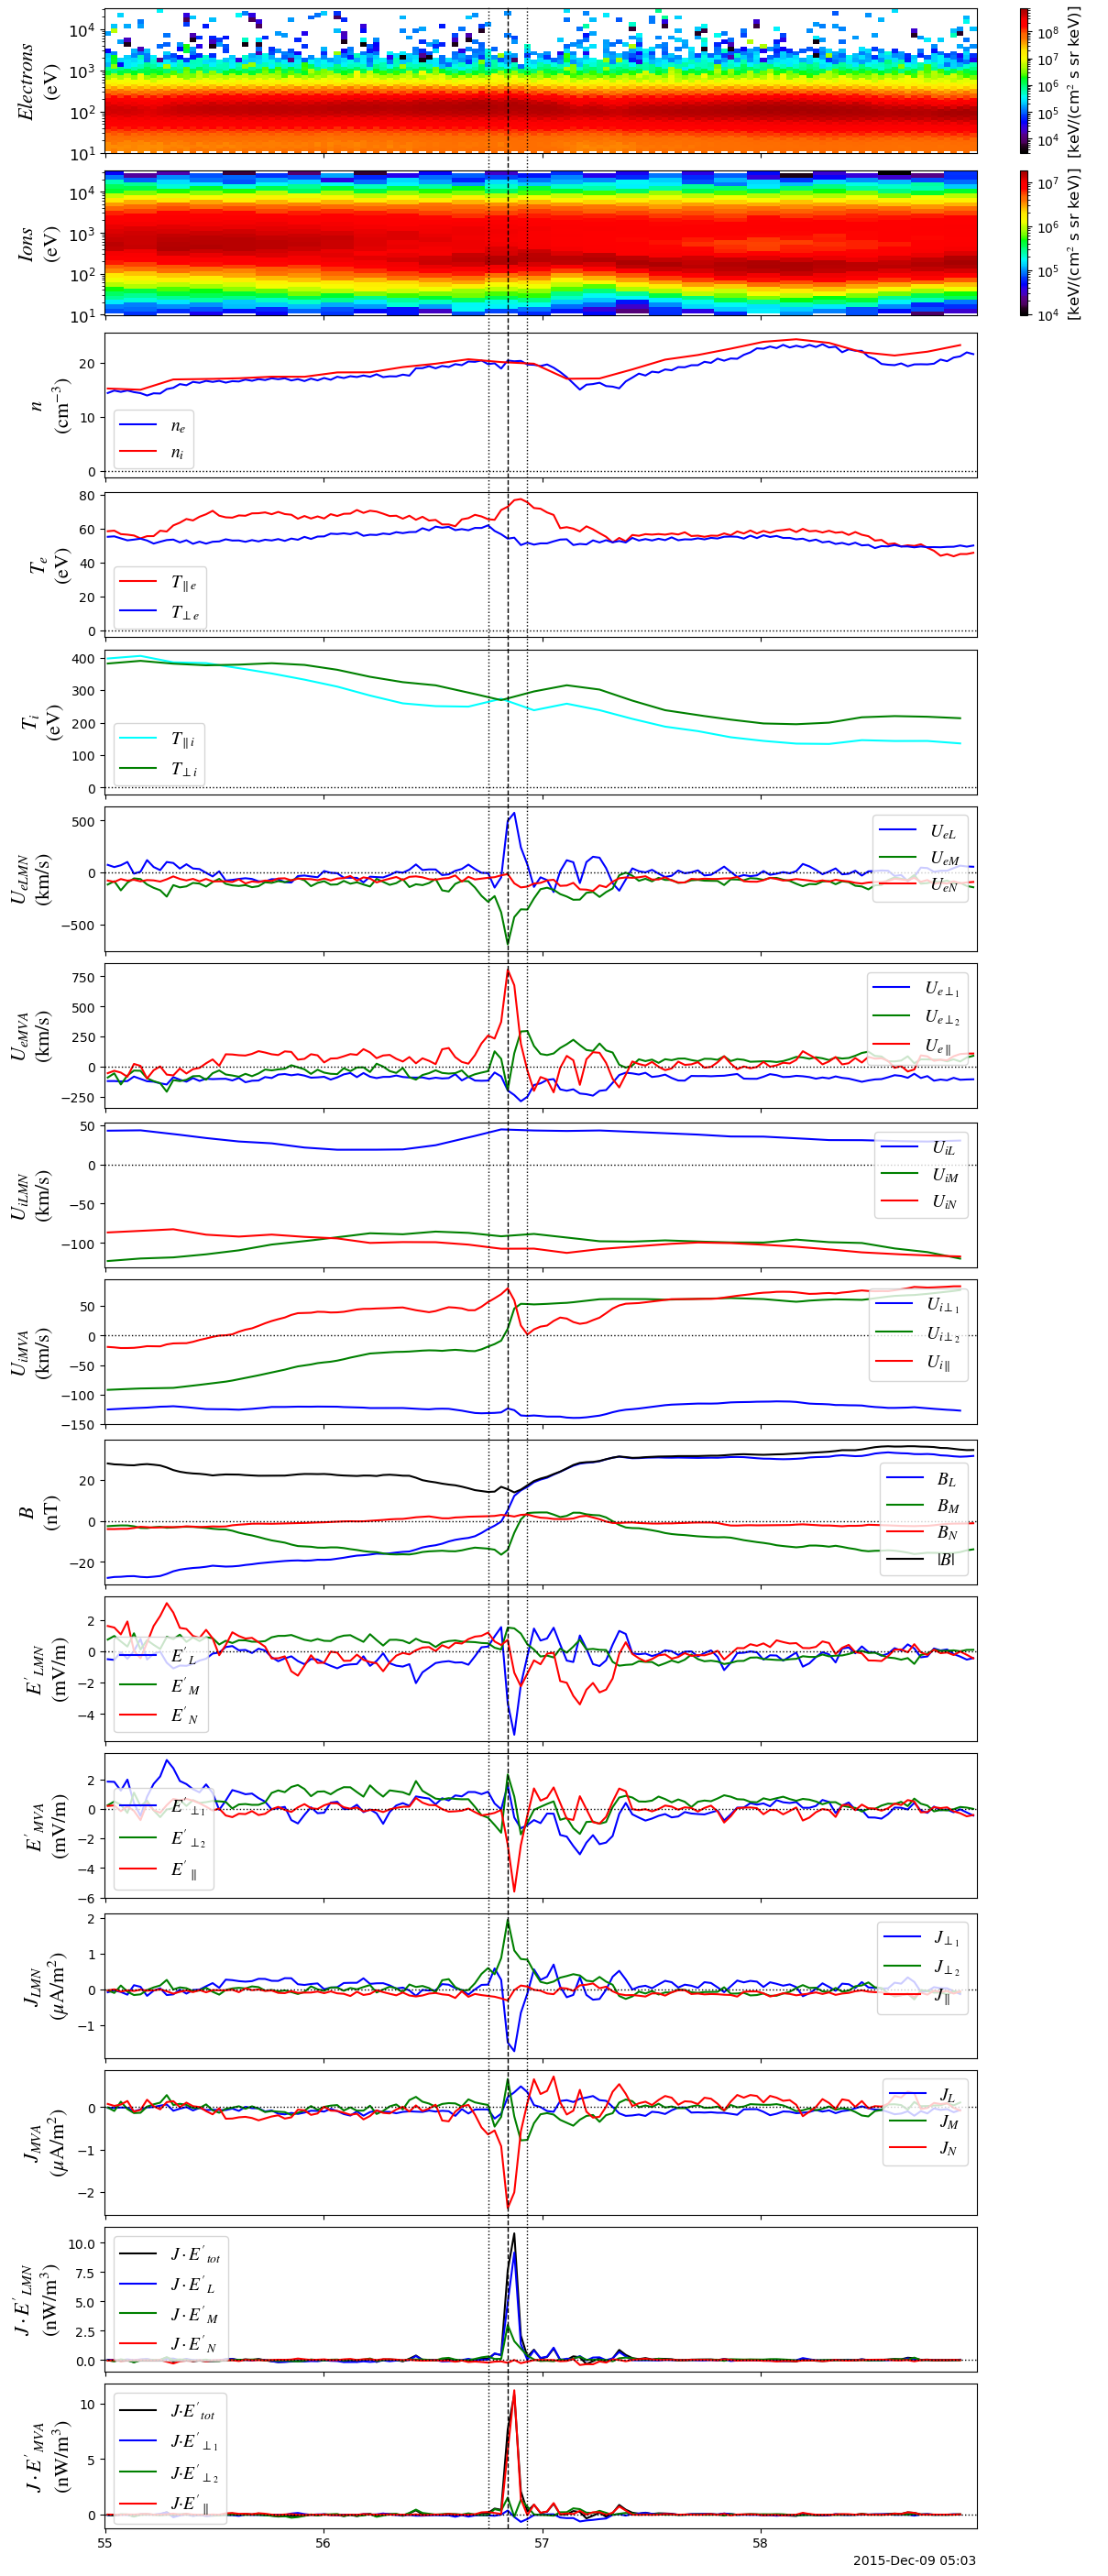

In [ ]:
from pyspedas import time_datetime

t_ax = time_datetime(ntime_e)
axs_label_fntsz = 16   # adjust as needed
legend_fntsz = 14
legendFrame = True

n_subplots = 16

fig, ax = plt.subplots(n_subplots, 1, figsize=(12, 28),  sharex=True, constrained_layout=True)

# First two subplots: energy spectra of electrons and ions
fig, ax0 = pyspedas.tplot('energy_e', fig = fig, axis = ax[0], display=False, return_plot_objects=True)
fig, ax1 = pyspedas.tplot('energy_i', fig = fig, axis = ax[1], display=False, return_plot_objects=True)
ax0.set_ylabel(r"$Electrons$" "\n" r"$(\mathrm{eV})$", fontsize=axs_label_fntsz)
ax1.set_ylabel(r"$Ions$" "\n" r"$(\mathrm{eV})$", fontsize=axs_label_fntsz)

# Third subplot: density of electrons and ions
ax[2].set_prop_cycle(color=['blue', 'red']) # custom color cycle
ax[2].plot(t_ax, den_e, linewidth=1.5, label=r'$n_e$')
ax[2].plot(t_ax, den_i, linewidth=1.5, label=r'$n_i$')
ax[2].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[2].set_ylabel(r"$n$" "\n" r"$(\mathrm{cm^{-3}})$", fontsize=axs_label_fntsz)
ax[2].legend(fontsize=legend_fntsz, frameon=legendFrame)

# Fourth subplot: electron temp profiles
ax[3].set_prop_cycle(color=['red', 'blue']) # custom color cycle
ax[3].plot(t_ax, te_para, linewidth=1.5, label=r'$T_{\parallel e}$')
ax[3].plot(t_ax, te_perp, linewidth=1.5, label=r'$T_{\perp e}$')
ax[3].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[3].set_ylabel(r"$T_e$" "\n" r"$(\mathrm{eV})$", fontsize=axs_label_fntsz)
ax[3].legend(fontsize=legend_fntsz, frameon=legendFrame)

# Fifth subplot: ion temp profiles
ax[4].set_prop_cycle(color=['red', 'blue']) # custom color cycle
ax[4].plot(t_ax, ti_para, linewidth=1.5, label=r'$T_{\parallel i}$')
ax[4].plot(t_ax, ti_perp, linewidth=1.5, label=r'$T_{\perp i}$')
ax[4].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[4].set_ylabel(r"$T_i$" "\n" r"$(\mathrm{eV})$", fontsize=axs_label_fntsz)
ax[4].legend(fontsize=legend_fntsz, frameon=legendFrame)

# Sixth subplot: electron bulk flow in lmn
ax[5].set_prop_cycle(color=['blue', 'green', 'red']) # custom color cycle
ax[5].plot(t_ax, bulk_ve_lmn, linewidth=1.5, label=["$U_{eL}$", "$U_{eM}$", "$U_{eN}$"])
ax[5].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[5].set_ylabel("$U_{eLMN}$" "\n" r"$(\mathrm{km/s})$", fontsize=axs_label_fntsz)
ax[5].legend(fontsize=legend_fntsz, frameon=legendFrame, loc='upper right')

# Seventh subplot: electron bulk flow in fac
ax[6].set_prop_cycle(color=['blue', 'green', 'red']) # custom color cycle
ax[6].plot(t_ax, bulk_ve_fac, linewidth=1.5, label=[r"$U_{e\perp_1}$", r"$U_{e\perp_2}$", 
                                                    r"$U_{e\parallel}$"])
ax[6].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[6].set_ylabel("$U_{eMVA}$" "\n" r"$(\mathrm{km/s})$", fontsize=axs_label_fntsz)
ax[6].legend(fontsize=legend_fntsz, frameon=legendFrame, loc='upper right')

# Eighth subplot: ion bulk flow in lmn
ax[7].set_prop_cycle(color=['blue', 'green', 'red']) # custom color cycle
ax[7].plot(t_ax, bulk_vi_lmn, linewidth=1.5, label=["$U_{iL}$", "$U_{iM}$", "$U_{iN}$"])
ax[7].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[7].set_ylabel("$U_{iLMN}$" "\n" r"$(\mathrm{km/s})$", fontsize=axs_label_fntsz)
ax[7].legend(fontsize=legend_fntsz, frameon=legendFrame, loc='upper right')

# Ninth subplot: ion bulk flow in fac
ax[8].set_prop_cycle(color=['blue', 'green', 'red']) # custom color cycle
ax[8].plot(t_ax, bulk_vi_fac, linewidth=1.5, label=[r"$U_{i\perp_1}$", r"$U_{i\perp_2}$", 
                                                    r"$U_{i\parallel}$"])
ax[8].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[8].set_ylabel(r"$U_{iMVA}$" "\n" r"$(\mathrm{km/s})$", fontsize=axs_label_fntsz)
ax[8].legend(fontsize=legend_fntsz, frameon=legendFrame, loc='upper right')

# Tenth subplot: B field in lmn
ax[9].set_prop_cycle(color=['blue', 'green', 'red', 'black']) # custom color cycle
ax[9].plot(t_ax, bvec_lmn, linewidth=1.5, label=['$B_L$', '$B_M$', '$B_N$'])
ax[9].plot(t_ax, bmag, linewidth=1.5, label='$|B|$')
ax[9].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[9].set_ylabel(r"$B$" "\n" r"$(\mathrm{nT})$", fontsize=axs_label_fntsz)
ax[9].legend(fontsize=legend_fntsz, frameon=legendFrame)

# Eleventh subplot: E field in LMN coordinates
ax[10].set_prop_cycle(color=['blue', 'green', 'red']) # custom color cycle
ax[10].plot(t_ax, evec_lmn, linewidth=1.5, label=["$E'_L$", "$E'_M$", "$E'_N$"])
ax[10].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[10].set_ylabel(r"$E'_{LMN}$" "\n" r"$(\mathrm{mV/m})$", fontsize=axs_label_fntsz)
ax[10].legend(fontsize=legend_fntsz, frameon=legendFrame)

# Twelfth subplot: E field in FAC coordinates
ax[11].set_prop_cycle(color=['blue', 'green', 'red']) # custom color cycle
ax[11].plot(t_ax, evec_fac, linewidth=1.5, label=[r"$E'_{\perp_1}$", r"$E'_{\perp_2}$", 
                                                  r"$E'_{\parallel}$"])
ax[11].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[11].set_ylabel("$E'_{MVA}$" "\n" r"$(\mathrm{mV/m})$", fontsize=axs_label_fntsz)
ax[11].legend(fontsize=legend_fntsz, frameon=legendFrame, loc='lower left')

# Thirteenth subplot: J vector in lmn coordinates
ax[12].set_prop_cycle(color=['blue', 'green', 'red']) # custom color cycle
ax[12].plot(t_ax, jvec_lmn*1e-3, linewidth=1.5, label=[r"$J_{\perp_1}$", r"$J_{\perp_2}$", 
                                                       r"$J_{\parallel}$"])
ax[12].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[12].set_ylabel(r"$J_{LMN}$" "\n" r"$(\mu\mathrm{A}/\mathrm{m}^2)$", fontsize=axs_label_fntsz)
ax[12].legend(fontsize=legend_fntsz, frameon=legendFrame, loc='upper right')


# Fourteenth subplot: J vector in fac coordinates
ax[13].set_prop_cycle(color=['blue', 'green', 'red']) # custom color cycle
ax[13].plot(t_ax, jvec_fac*1e-3, linewidth=1.5, label=["$J_L$", "$J_M$", "$J_N$"])
ax[13].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[13].set_ylabel(r"$J_{MVA}$" "\n" r"$(\mu\mathrm{A}/\mathrm{m}^2)$", fontsize=axs_label_fntsz)
ax[13].legend(fontsize=legend_fntsz, frameon=legendFrame, loc='upper right')

# Fifteenth subplot: J.E' in lmn coordinates
ax[14].set_prop_cycle(color=['black', 'blue', 'green', 'red']) # custom color cycle
ax[14].plot(t_ax, jdotE_lmn, linewidth=1.5, 
    label=[r"$J \cdot E'_{tot}$", r"$J \cdot E'_{L}$", r"$J \cdot E'_{M}$", r"$J \cdot E'_{N}$"])
ax[14].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[14].set_ylabel(r"$J \cdot E'_{LMN}$" "\n" r"$(\mathrm{nW/m^3})$", fontsize=axs_label_fntsz)
ax[14].legend(fontsize=legend_fntsz, loc='upper left')

# Sixteenth subplot: J.E' in fac coordinates
ax[15].set_prop_cycle(color=['black', 'blue', 'green', 'red']) # custom color cycle
ax[15].plot(t_ax, jdotE_fac, linewidth=1.5, 
    label=[r"$J·E'_{tot}$", r"$J·E'_{\perp_1}$", r"$J·E'_{\perp_2}$", r"$J·E'_{\parallel}$"])
ax[15].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[15].set_ylabel(r"$J \cdot E'_{MVA}$" "\n" r"$(\mathrm{nW/m^3})$", fontsize=axs_label_fntsz)
ax[15].legend(fontsize=legend_fntsz, loc='upper left')


# Vertical reference lines
y_up = n_subplots + 1.425
ax[-1].axvline(x=dt_obj, ymin=0, ymax=y_up, color='k', linestyle='dashed', 
    linewidth=1, clip_on=False)
ax[-1].axvline(x=dt_obj0, ymin=0, ymax=y_up, color='k', linestyle='dotted', 
    linewidth=1, clip_on=False)
ax[-1].axvline(x=dt_obj1, ymin=0, ymax=y_up, color='k', linestyle='dotted', 
    linewidth=1, clip_on=False)

plt.show()

### Writing a single function to do all of the above for any probe
Commented out since we transfered the main function to the main package file

In [25]:
# import os
# import numpy as np
# from scipy.constants import elementary_charge as q_e
# from pyspedas import get_data, tplot_rename
# from pyspedas.projects import mms

# from fipcore.utils.helper_utils import downsample_cad, upsample_cad, compute_beta_par, \
#     compute_beta_perp, compute_beta_scalar
# from fipcore.utils.coord_utils import rotate_to_fac, rotate_to_lmn
# from fipcore.analysis.jdotE_proc import compute_jdotE
# import fipcore.utils.io_utils as iout

# def fpc_mrx_plasma_params(trange, probe='1', data_rate='brst', level='l2', species='e', 
#             bg_ratio=None, bin_width_frac=0.25, subtract_f0=False, get_support_data=True, 
#             no_update=True):

#     # --- MMS Data Loading --- 
#     # Read in FPI Data
#     fpi_varlist = [f'mms{probe}_des_energyspectr_omni_brst', 
#         f'mms{probe}_dis_energyspectr_omni_brst', f'mms{probe}_des_numberdensity_brst', 
#         f'mms{probe}_dis_numberdensity_brst', f'mms{probe}_des_temppara_brst', 
#         f'mms{probe}_dis_temppara_brst', f'mms{probe}_des_tempperp_brst', 
#         f'mms{probe}_dis_tempperp_brst', f'mms{probe}_des_bulkv_gse_brst', 
#         f'mms{probe}_dis_bulkv_gse_brst']
    
#     fpi_vars = mms.fpi(trange=trange, probe=probe, data_rate=data_rate, level=level, 
#                     datatype=['des-moms', 'dis-moms'], time_clip=True, 
#                     varnames=fpi_varlist, get_support_data=get_support_data, 
#                     no_update=no_update)

#     # Read in FGM Data
#     fgm_vars = mms.fgm(trange=trange, probe=probe, data_rate=data_rate, level=level,
#         varnames=f'mms{probe}_fgm_b_gse_brst_l2', time_clip=True, 
#         get_support_data=get_support_data, no_update=no_update)


#     # Renaming tplot variabless
#     tplot_rename(f'mms{probe}_des_energyspectr_omni_brst', 'energy_e')
#     tplot_rename(f'mms{probe}_dis_energyspectr_omni_brst', 'energy_i')
#     tplot_rename(f'mms{probe}_des_numberdensity_brst', 'den_e')
#     tplot_rename(f'mms{probe}_dis_numberdensity_brst', 'den_i')
#     tplot_rename(f'mms{probe}_des_temppara_brst', 'te_para')
#     tplot_rename(f'mms{probe}_dis_temppara_brst', 'ti_para')
#     tplot_rename(f'mms{probe}_des_tempperp_brst', 'te_perp')
#     tplot_rename(f'mms{probe}_dis_tempperp_brst', 'ti_perp')
#     tplot_rename(f'mms{probe}_des_bulkv_gse_brst', 'bulk_ve_gse')
#     tplot_rename(f'mms{probe}_dis_bulkv_gse_brst', 'bulk_vi_gse')
#     tplot_rename(f'mms{probe}_fgm_b_gse_brst_l2', 'bvec_gse')

#     # Matching vars to DES cadence of 30 ms
#     downsample_cad('bvec_gse', 'bulk_ve_gse', trange=trange, newname='bvec_gse_dwn')
#     upsample_cad('energy_i', 'energy_e', newname='energy_i_up')
#     upsample_cad('den_i', 'energy_e', newname='den_i_up')
#     upsample_cad('ti_para', 'energy_e', newname='ti_para_up')
#     upsample_cad('ti_perp', 'energy_e', newname='ti_perp_up')
#     upsample_cad('bulk_vi_gse', 'bulk_ve_gse', newname='bulk_vi_gse_up')

#     # Extract the numpy arrays from the tplot vars
#     _, den_e = get_data('den_e')
#     _, den_i = get_data('den_i_up')
#     _, te_para = get_data('te_para')
#     _, ti_para = get_data('ti_para_up')
#     _, te_perp = get_data('te_perp')
#     _, ti_perp = get_data('ti_perp_up')
#     ntime_e, bulk_ve_gse = get_data('bulk_ve_gse')
#     _, bulk_vi_gse = get_data('bulk_vi_gse_up')
#     _, bvec_gse = get_data('bvec_gse_dwn')
#     bmag = bvec_gse[:,3]

#     # Data path setup
#     # project_root = os.path.dirname(os.path.dirname(os.path.dirname(__file__)))
#     project_root= ".."
#     data_dir = os.path.join(project_root, "data")
#     type_tag = 'df' if subtract_f0 else 'f'
#     hfile_pref = f'mms{probe}_{data_rate}_{type_tag}_{species}_{bin_width_frac:.2f}'
#     hfile = os.path.join(data_dir, iout.mms_name_make(hfile_pref, trange[0], trange[1]))

#     # Reading in the E-field, fac & lmn matrices
#     with h5py.File(hfile, "r") as f:
#         evec_gse = f["gse"]["evec_lor"][:]
#         evec_fac = f["fac"]["evec_lor"][:]
#         evec_lmn = f["lmn"]["evec_lor"][:]
#         fac_mat = f["fac"]['rot_mat'][...]
#         lmn_mat = f["lmn"]['rot_mat'][...]

#     # Computing current density in nA/m^2 in gse, fac and lmn
#     jvec_gse = den_e.reshape(-1, 1) * q_e * (bulk_vi_gse - bulk_ve_gse)*1e18
#     # cm^-3 * C * km/s = 10^18 nA/m^2 
#     _, jvec_fac = rotate_to_fac(jvec_gse, fac_mat)
#     _, jvec_lmn = rotate_to_lmn(jvec_gse, lmn_mat)

#     # Computing jdotE in gse, fac and lmn
#     _, jdotE_gse, jdotE_gse0, jdotE_gse1, jdotE_gse2 = compute_jdotE(jvec_gse, evec_gse)
#     jdotE_gse = np.column_stack([jdotE_gse, jdotE_gse0, jdotE_gse1, jdotE_gse2])
    
#     _, jdotE_fac, jdotE_fac0, jdotE_fac1, jdotE_fac2 = compute_jdotE(jvec_fac, evec_fac)
#     jdotE_fac = np.column_stack([jdotE_fac, jdotE_fac0, jdotE_fac1, jdotE_fac2])

#     _, jdotE_lmn, jdotE_lmn0, jdotE_lmn1, jdotE_lmn2 = compute_jdotE(jvec_lmn, evec_lmn)
#     jdotE_lmn = np.column_stack([jdotE_lmn, jdotE_lmn0, jdotE_lmn1, jdotE_lmn2])

#     # Rotating bulk flow to fac and lmn
#     _, bulk_ve_fac = rotate_to_fac(bulk_ve_gse, fac_mat)
#     _, bulk_vi_fac = rotate_to_fac(bulk_vi_gse, fac_mat)

#     _, bulk_ve_lmn = rotate_to_lmn(bulk_ve_gse, lmn_mat)
#     _, bulk_vi_lmn = rotate_to_lmn(bulk_vi_gse, lmn_mat)

#     # Computing plasma beta profiles
#     beta_e_para = compute_beta_par(den_e, te_para, bmag)
#     beta_e_perp = compute_beta_perp(den_e, te_perp, bmag)
#     beta_e_scalar = compute_beta_scalar(den_e, te_para, te_perp, bmag)

#     beta_i_para = compute_beta_par(den_i, ti_para, bmag)
#     beta_i_perp = compute_beta_perp(den_i, ti_perp, bmag)
#     beta_i_scalar = compute_beta_scalar(den_i, ti_para, ti_perp, bmag)

#     # --- Grouping Data for HDF5 ---
#     dat_grps = {
#         "meta":{
#             "time": ntime_e,
#             "bg_ratio": bg_ratio,
#             "den_e": den_e,
#             "den_i": den_i,
#             "te_para": te_para,
#             "ti_para": ti_para,
#             "te_perp": te_perp,
#             "ti_perp": ti_perp,
#             "bmag": bmag,
#             "beta_e_para":   beta_e_para,
#             "beta_e_perp":   beta_e_perp,
#             "beta_e_scalar": beta_e_scalar,
#             "beta_i_para":   beta_i_para,
#             "beta_i_perp":   beta_i_perp,
#             "beta_i_scalar": beta_i_scalar,
#         },
#         "gse": {
#             "bulk_ve": bulk_ve_gse,
#             "bulk_vi": bulk_vi_gse,
#             "jvec": jvec_gse,
#             "jdotE": jdotE_gse
#         },
#         "fac": {
#             "bulk_ve": bulk_ve_fac,
#             "bulk_vi": bulk_vi_fac,
#             "jvec": jvec_fac,
#             "jdotE": jdotE_fac
#         },
#         "lmn": {
#             "bulk_ve": bulk_ve_lmn,
#             "bulk_vi": bulk_vi_lmn,
#             "jvec": jvec_lmn,
#             "jdotE": jdotE_lmn
#         }
#     }

#     # --- Saving to a .h5 file ---
#     # Note: Ensure the variable name passed here matches your dictionary (dat_grps)
#     iout.h5sav(hfile, dat_grps)

#     print(f"Data saved to file: {hfile}")
    
#     return hfile

In [27]:
fpc.fpc_mrx_plasma_params(trange, probe='1', species='e', bg_ratio=0.5, subtract_f0=True)

12-Aug-26 10:46:20: Searching for local files...
12-Aug-26 10:46:20: Loading: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/des-moms/2015/12/09/mms1_fpi_brst_l2_des-moms_20151209050044_v3.3.0.cdf
12-Aug-26 10:46:20: Searching for local files...
12-Aug-26 10:46:20: Loading: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/dis-moms/2015/12/09/mms1_fpi_brst_l2_dis-moms_20151209050044_v3.3.0.cdf
12-Aug-26 10:46:20: Loading files for group: probe: 1, drate: brst, level: l2, datatype: des-moms, after sorting and filtering:
12-Aug-26 10:46:20: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/des-moms/2015/12/09/mms1_fpi_brst_l2_des-moms_20151209050044_v3.3.0.cdf
12-Aug-26 10:46:20: Loading files for group: probe: 1, drate: brst, level: l2, datatype: dis-moms, after sorting and filtering:
12-Aug-26 10:46:20: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/dis-moms/2015/12/09/mms1_fpi_brst_l2_dis-moms_20151209050044_v3.3.0.cdf
12-Aug-26 10:46:20: The name mms1_des_errorflags_brst is currently n

(133, 4) (133,)
Input data are Numpy Arrays, no time array will be returned!
Input data are Numpy Arrays, no time array will be returned!
Input data are Numpy Arrays, no time array will be returned!
Input data are Numpy Arrays, no time array will be returned!
Input data are Numpy Arrays, no time array will be returned!
Input data are Numpy Arrays, no time array will be returned!

HDF5 write complete. Current file structure:

[fac] -> ['Cprime_raw', 'Cprime_vol', 'JE_tot', 'bCprime_avg', 'bCprime_vol', 'binc', 'binc_n', 'bulk_ve', 'bulk_vi', 'bvdf_avg', 'bvdf_vol', 'c_avg', 'c_vol', 'edges', 'edges_n', 'evec_lor', 'jdotE', 'jvec', 'npts_vol', 'npts_vol_cp', 'rot_mat', 'vdf_eq', 'vmap', 'vv']
[gse] -> ['bulk_ve', 'bulk_vi', 'bvec', 'evec_lor', 'jdotE', 'jvec', 'vv']
[lmn] -> ['Cprime_raw', 'Cprime_vol', 'JE_tot', 'bCprime_avg', 'bCprime_vol', 'binc', 'binc_n', 'bulk_ve', 'bulk_vi', 'bvdf_avg', 'bvdf_vol', 'bvec', 'c_avg', 'c_vol', 'edges', 'edges_n', 'evec_lor', 'jdotE', 'jvec', 'npts_vo

'/Users/rejohn/Library/CloudStorage/OneDrive-WestVirginiaUniversity/1 - Active Projects/MMS FPC/MMS FPC Analysis/FPC_mRx/data/mms1_brst_df_e_0.25_20151209_050355_050359.h5'

checking if units are stored correctly or not

In [28]:
with h5py.File(hfile,'r') as f:
    print(f['lmn']['jvec'].attrs['units'])

nA/m^2


In [29]:
with h5py.File(hfile, "r") as f:
    print(f['meta']['probe'].attrs['units'])

N/A


### Probe 2

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os
import h5py
import fipcore as fpc
import pyspedas
from pyspedas.projects import mms
from pyspedas import get_data, tplot_rename, tplot_restore

In [3]:
trange = ['2015-12-09/05:03:55', '2015-12-09/05:03:59']
species = 'e'
bin_width_frac = 0.25
data_dir = os.path.join("..", "data")
subtract_f0 = True
type_tag = 'df' if subtract_f0 else 'f'
probe = '2'
data_rate = 'brst'
level = 'l2'
get_support_data = True
no_update = True
hfile_pref = f'mms{probe}_{data_rate}_{type_tag}_{species}_{bin_width_frac:.2f}'
hfile = os.path.join(data_dir, fpc.mms_name_make(hfile_pref, trange[0], trange[1]))

In [4]:
hfile

'../data/mms2_brst_df_e_0.25_20151209_050355_050359.h5'

In [17]:
with h5py.File(hfile, "r") as f:
    ntime_e = f["meta"]["time"][...]
    bvec_lmn = f["lmn"]["bvec"][...]
    evec_lmn = f["lmn"]["evec_lor"][...]
    evec_fac = f["fac"]["evec_lor"][...]
    jvec_lmn = f["lmn"]["jvec"][...]
    jvec_fac = f["fac"]["jvec"][...]
    jdotE_fac = f["fac"]["jdotE"][...]
    jdotE_lmn = f["lmn"]["jdotE"][...]
    fac_mat = f["fac"]['rot_mat'][...]
    lmn_mat = f["lmn"]['rot_mat'][...]
    den_e = f['meta']['den_e'][...]
    den_i = f['meta']['den_i'][...]
    te_para = f['meta']['te_para'][...]
    te_perp = f['meta']['te_perp'][...]
    ti_para = f['meta']['ti_para'][...]
    ti_perp = f['meta']['ti_perp'][...]

In [18]:
tplot_file = hfile.replace('.h5', '.pyspd')

In [19]:
tplot_file

'../data/mms2_brst_df_e_0.25_20151209_050355_050359.pyspd'

In [20]:
pyspedas.tplot_restore(tplot_file)

In [21]:
idx = 61
from pyspedas import time_datetime
dt_obj = time_datetime(ntime_e[idx])
dt_obj0 = time_datetime(ntime_e[idx-3])
dt_obj1 = time_datetime(ntime_e[idx+3])

12-Aug-26 11:27:59: specplot_make_1d_ybins: Direction of increase of input bin centers was indeterminate (all-nan, all-same, or non-monotonic) at 3 of 134 time indices.


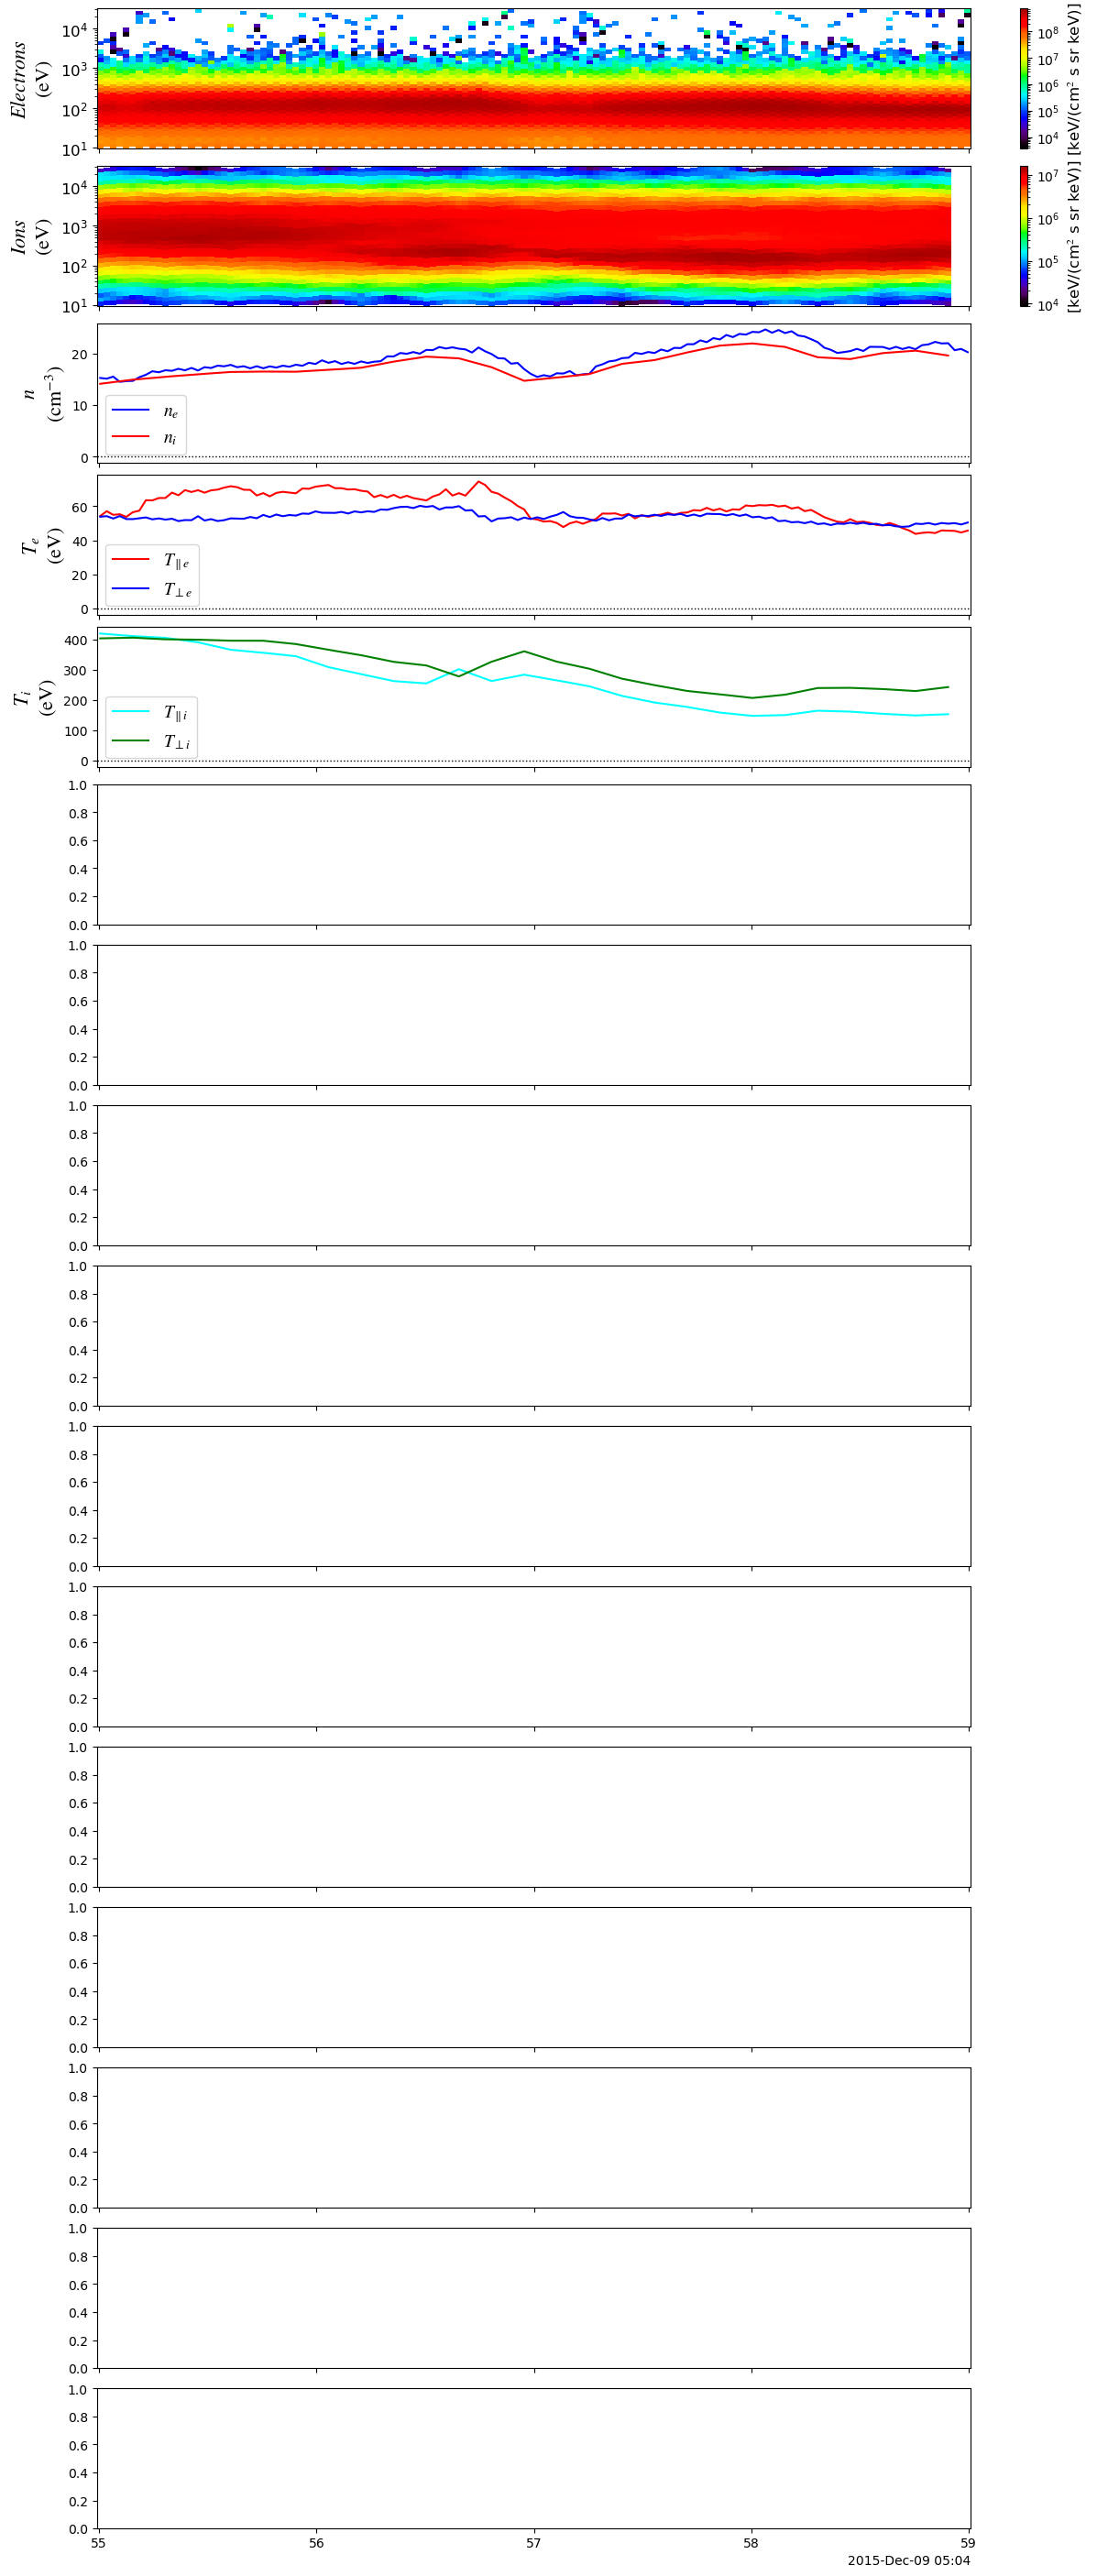

In [22]:
from pyspedas import time_datetime

t_ax = time_datetime(ntime_e)
axs_label_fntsz = 16   # adjust as needed
legend_fntsz = 14
legendFrame = True

n_subplots = 16

fig, ax = plt.subplots(n_subplots, 1, figsize=(12, 28),  sharex=True, constrained_layout=True)

# First two subplots: energy spectra of electrons and ions
fig, ax0 = pyspedas.tplot('energy_e', fig = fig, axis = ax[0], display=False, return_plot_objects=True)
fig, ax1 = pyspedas.tplot('energy_i_up', fig = fig, axis = ax[1], display=False, return_plot_objects=True)
ax0.set_ylabel(r"$Electrons$" "\n" r"$(\mathrm{eV})$", fontsize=axs_label_fntsz)
ax1.set_ylabel(r"$Ions$" "\n" r"$(\mathrm{eV})$", fontsize=axs_label_fntsz)

# Third subplot: density of electrons and ions
ax[2].set_prop_cycle(color=['blue', 'red']) # custom color cycle
ax[2].plot(t_ax, den_e, linewidth=1.5, label=r'$n_e$')
ax[2].plot(t_ax, den_i, linewidth=1.5, label=r'$n_i$')
ax[2].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[2].set_ylabel(r"$n$" "\n" r"$(\mathrm{cm^{-3}})$", fontsize=axs_label_fntsz)
ax[2].legend(fontsize=legend_fntsz, frameon=legendFrame)

# Fourth subplot: electron temp profiles
ax[3].set_prop_cycle(color=['red', 'blue']) # custom color cycle
ax[3].plot(t_ax, te_para, linewidth=1.5, label=r'$T_{\parallel e}$')
ax[3].plot(t_ax, te_perp, linewidth=1.5, label=r'$T_{\perp e}$')
ax[3].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[3].set_ylabel(r"$T_e$" "\n" r"$(\mathrm{eV})$", fontsize=axs_label_fntsz)
ax[3].legend(fontsize=legend_fntsz, frameon=legendFrame)

# Fifth subplot: ion temp profiles
ax[4].set_prop_cycle(color=['cyan', 'green']) # custom color cycle
ax[4].plot(t_ax, ti_para, linewidth=1.5, label=r'$T_{\parallel i}$')
ax[4].plot(t_ax, ti_perp, linewidth=1.5, label=r'$T_{\perp i}$')
ax[4].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
ax[4].set_ylabel(r"$T_i$" "\n" r"$(\mathrm{eV})$", fontsize=axs_label_fntsz)
ax[4].legend(fontsize=legend_fntsz, frameon=legendFrame)

# # Sixth subplot: electron bulk flow in lmn
# ax[5].set_prop_cycle(color=['blue', 'green', 'red']) # custom color cycle
# ax[5].plot(t_ax, bulk_ve_lmn, linewidth=1.5, label=["$U_{eL}$", "$U_{eM}$", "$U_{eN}$"])
# ax[5].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
# ax[5].set_ylabel("$U_{eLMN}$" "\n" r"$(\mathrm{km/s})$", fontsize=axs_label_fntsz)
# ax[5].legend(fontsize=legend_fntsz, frameon=legendFrame, loc='upper right')

# # Seventh subplot: electron bulk flow in fac
# ax[6].set_prop_cycle(color=['blue', 'green', 'red']) # custom color cycle
# ax[6].plot(t_ax, bulk_ve_fac, linewidth=1.5, label=[r"$U_{e\perp_1}$", r"$U_{e\perp_2}$", 
#                                                     r"$U_{e\parallel}$"])
# ax[6].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
# ax[6].set_ylabel("$U_{eMVA}$" "\n" r"$(\mathrm{km/s})$", fontsize=axs_label_fntsz)
# ax[6].legend(fontsize=legend_fntsz, frameon=legendFrame, loc='upper right')

# # Eighth subplot: ion bulk flow in lmn
# ax[7].set_prop_cycle(color=['blue', 'green', 'red']) # custom color cycle
# ax[7].plot(t_ax, bulk_vi_lmn, linewidth=1.5, label=["$U_{iL}$", "$U_{iM}$", "$U_{iN}$"])
# ax[7].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
# ax[7].set_ylabel("$U_{iLMN}$" "\n" r"$(\mathrm{km/s})$", fontsize=axs_label_fntsz)
# ax[7].legend(fontsize=legend_fntsz, frameon=legendFrame, loc='upper right')

# # Ninth subplot: ion bulk flow in fac
# ax[8].set_prop_cycle(color=['blue', 'green', 'red']) # custom color cycle
# ax[8].plot(t_ax, bulk_vi_fac, linewidth=1.5, label=[r"$U_{i\perp_1}$", r"$U_{i\perp_2}$", 
#                                                     r"$U_{i\parallel}$"])
# ax[8].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
# ax[8].set_ylabel(r"$U_{iMVA}$" "\n" r"$(\mathrm{km/s})$", fontsize=axs_label_fntsz)
# ax[8].legend(fontsize=legend_fntsz, frameon=legendFrame, loc='upper right')

# # Tenth subplot: B field in lmn
# ax[9].set_prop_cycle(color=['blue', 'green', 'red', 'black']) # custom color cycle
# ax[9].plot(t_ax, bvec_lmn, linewidth=1.5, label=['$B_L$', '$B_M$', '$B_N$'])
# ax[9].plot(t_ax, bmag, linewidth=1.5, label='$|B|$')
# ax[9].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
# ax[9].set_ylabel(r"$B$" "\n" r"$(\mathrm{nT})$", fontsize=axs_label_fntsz)
# ax[9].legend(fontsize=legend_fntsz, frameon=legendFrame)

# # Eleventh subplot: E field in LMN coordinates
# ax[10].set_prop_cycle(color=['blue', 'green', 'red']) # custom color cycle
# ax[10].plot(t_ax, evec_lmn, linewidth=1.5, label=["$E'_L$", "$E'_M$", "$E'_N$"])
# ax[10].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
# ax[10].set_ylabel(r"$E'_{LMN}$" "\n" r"$(\mathrm{mV/m})$", fontsize=axs_label_fntsz)
# ax[10].legend(fontsize=legend_fntsz, frameon=legendFrame)

# # Twelfth subplot: E field in FAC coordinates
# ax[11].set_prop_cycle(color=['blue', 'green', 'red']) # custom color cycle
# ax[11].plot(t_ax, evec_fac, linewidth=1.5, label=[r"$E'_{\perp_1}$", r"$E'_{\perp_2}$", 
#                                                   r"$E'_{\parallel}$"])
# ax[11].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
# ax[11].set_ylabel("$E'_{MVA}$" "\n" r"$(\mathrm{mV/m})$", fontsize=axs_label_fntsz)
# ax[11].legend(fontsize=legend_fntsz, frameon=legendFrame, loc='lower left')

# # Thirteenth subplot: J vector in lmn coordinates
# ax[12].set_prop_cycle(color=['blue', 'green', 'red']) # custom color cycle
# ax[12].plot(t_ax, jvec_lmn*1e-3, linewidth=1.5, label=[r"$J_{\perp_1}$", r"$J_{\perp_2}$", 
#                                                        r"$J_{\parallel}$"])
# ax[12].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
# ax[12].set_ylabel(r"$J_{LMN}$" "\n" r"$(\mu\mathrm{A}/\mathrm{m}^2)$", fontsize=axs_label_fntsz)
# ax[12].legend(fontsize=legend_fntsz, frameon=legendFrame, loc='upper right')


# # Fourteenth subplot: J vector in fac coordinates
# ax[13].set_prop_cycle(color=['blue', 'green', 'red']) # custom color cycle
# ax[13].plot(t_ax, jvec_fac*1e-3, linewidth=1.5, label=["$J_L$", "$J_M$", "$J_N$"])
# ax[13].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
# ax[13].set_ylabel(r"$J_{MVA}$" "\n" r"$(\mu\mathrm{A}/\mathrm{m}^2)$", fontsize=axs_label_fntsz)
# ax[13].legend(fontsize=legend_fntsz, frameon=legendFrame, loc='upper right')

# # Fifteenth subplot: J.E' in lmn coordinates
# ax[14].set_prop_cycle(color=['black', 'blue', 'green', 'red']) # custom color cycle
# ax[14].plot(t_ax, jdotE_lmn, linewidth=1.5, 
#     label=[r"$J \cdot E'_{tot}$", r"$J \cdot E'_{L}$", r"$J \cdot E'_{M}$", r"$J \cdot E'_{N}$"])
# ax[14].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
# ax[14].set_ylabel(r"$J \cdot E'_{LMN}$" "\n" r"$(\mathrm{nW/m^3})$", fontsize=axs_label_fntsz)
# ax[14].legend(fontsize=legend_fntsz, loc='upper left')

# # Sixteenth subplot: J.E' in fac coordinates
# ax[15].set_prop_cycle(color=['black', 'blue', 'green', 'red']) # custom color cycle
# ax[15].plot(t_ax, jdotE_fac, linewidth=1.5, 
#     label=[r"$J·E'_{tot}$", r"$J·E'_{\perp_1}$", r"$J·E'_{\perp_2}$", r"$J·E'_{\parallel}$"])
# ax[15].axhline(0, color='k', linestyle='dotted', linewidth=1.0)
# ax[15].set_ylabel(r"$J \cdot E'_{MVA}$" "\n" r"$(\mathrm{nW/m^3})$", fontsize=axs_label_fntsz)
# ax[15].legend(fontsize=legend_fntsz, loc='upper left')


# Vertical reference lines
# y_up = n_subplots + 1.425
# ax[-1].axvline(x=dt_obj, ymin=0, ymax=y_up, color='k', linestyle='dashed', 
#     linewidth=1, clip_on=False)
# ax[-1].axvline(x=dt_obj0, ymin=0, ymax=y_up, color='k', linestyle='dotted', 
#     linewidth=1, clip_on=False)
# ax[-1].axvline(x=dt_obj1, ymin=0, ymax=y_up, color='k', linestyle='dotted', 
#     linewidth=1, clip_on=False)

plt.show()

# VDF Plot for t=62, the reconnection time

In [ ]:
vdf_vol_fac.shape

In [ ]:
vdf_12, vdf_23, vdf_13 = fpc.slice3d_to_2d(vdf_vol_fac, time_slice=62)

In [ ]:
vdf_fac_list = (vdf_12, vdf_13, vdf_23.T) # The order is xy, xz and zy
ax_pairs = ((x_fac, y_fac), (x_fac, z_fac), (z_fac, y_fac))
ax_lbls = [r"$v_{\perp 1}/v_{te}$", r"$v_{\perp 2}/v_{te}$", 
                           r"$v_{\parallel}/v_{te}$"]
axlabel_pairs = ((ax_lbls[0], ax_lbls[1]), (ax_lbls[0], ax_lbls[2]), 
                    (ax_lbls[2], ax_lbls[1])) # xy, xz, zy

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), dpi=100, constrained_layout=True)
axis_fntsz = 16
cbar_ht=0.047

for i in range(3):
    vmin, vmax = fpc.global_vmin_vmax_vdf(vdf_fac_list[i])
    ax1, ax2 = ax_pairs[i]
    xlabel, ylabel = axlabel_pairs[i]
    im1, _ = fpc.imagecont_vdf(ax1, ax2, vdf_fac_list[i], xlabel=xlabel, 
                ylabel=ylabel, ax=axes[i], vmin=vmin, vmax=vmax, 
                axis_fntsz=axis_fntsz)
    height, width = len(ax2), len(ax1)
    cbar = fig.colorbar(im1, ax=axes[i], fraction=cbar_ht*height/width, pad=0.08)
    cbar.set_label(r"[m$^{-3}$]")

# Folded E-parallel FPC plot for t=62, the reconnection event

In [ ]:
c_vol_fac.shape, cz_folds_fac.shape

In [ ]:
cz_12, cz_23, cz_13 = fpc.slice3d_to_2d(c_vol_fac[2], time_slice=62)

In [ ]:
cz_fac_list = (cz_12, cz_folds_fac[0, :, :, 62], cz_folds_fac[1, :, :, 62]) # The order is xy, xz and zy   

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), dpi=100, constrained_layout=True)
axis_fntsz = 16
cbar_ht=0.047

for i in range(3):
    vmin, vmax = fpc.global_vmin_vmax_fpc(cz_fac_list[i])
    ax1, ax2 = ax_pairs[i]
    xlabel, ylabel = axlabel_pairs[i]
    im2, _ = fpc.imagecont_fpc(ax1, ax2, cz_fac_list[i], xlabel=xlabel, 
                ylabel=ylabel, ax=axes[i], vmin=vmin, vmax=vmax, 
                axis_fntsz=axis_fntsz)
    height, width = len(ax2), len(ax1)
    cbar = fig.colorbar(im2, ax=axes[i], fraction=cbar_ht*height/width, pad=0.005)
    cbar.set_label(r"[W m$^{-3}$]")


# Subtracted FPC integrated

In [ ]:
data_dir = os.path.join("..", "data")
subtract_f0 = True
type_tag = 'df' if subtract_f0 else 'f'
probe = '1'
data_rate = 'brst'
level = 'l2'
get_support_data = True
no_update = True
hfile_pref = f'mms{probe}_{data_rate}_{type_tag}_{species}_{bin_width_frac:.2f}'
hfile_df = os.path.join(data_dir, fpc.mms_name_make(hfile_pref, trange[0], trange[1]))

In [ ]:
hfile_df

In [ ]:
with h5py.File(hfile_df, 'r') as f:
    print(f['fac'].keys())

In [ ]:
with h5py.File(hfile_df, "r") as f:
    ntime = f["meta"]["time"][:]
    c_vol_fac = f["fac"]["c_vol"][...]
    dvdf_vol_fac = f["fac"]["bvdf_vol"][...]
    vpar_fac = f["fac"]["binc_n"][:]
    vv_fac = f["fac"]["vv"][:] 

In [ ]:
c_vol_fac.shape, vpar_fac.shape, dvdf_vol_fac.shape

Only selecting the parallel component of the FPC signature:

In [ ]:
c_vol_fac_par = c_vol_fac[2]

In [ ]:
c_vol_fac_par_t62 = c_vol_fac_par[:, :, :, 62]

In [ ]:
c_vol_fac_par_t62.shape

integrating over both perp directions

In [ ]:
c_line_fac_par_t62 = np.nansum(c_vol_fac_par_t62, axis=(0, 1))

In [ ]:
c_line_fac_par_t62.shape

In [ ]:
vv_fac.shape

In [ ]:
import matplotlib.pyplot as plt

# Assuming you have arrays:
# vpar_norm  → normalized parallel velocity (same scale as v_parallel/v_te)
# C_line     → integrated C_E_parallel array (shape = (28,))

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(vpar_fac, c_line_fac_par_t62, color='blue', linewidth=3)

# Axis labels
ax.set_xlabel(r'$v_{\parallel}/v_{te}$', fontsize=20)
ax.set_ylabel(r'$C_{E\parallel}$', fontsize=20)

# Style tweaks to match the reference plot
ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)
ax.tick_params(labelsize=16)
ax.set_xlim([-3, 3])

plt.tight_layout()
plt.show()

## Subtract vdf integrated
Selecting the subtracted vdf for t = 62

In [ ]:
dvdf_vol_fac_t62 = dvdf_vol_fac[:, :, :, 62]

In [ ]:
dvdf_vol_fac_t62.shape

Integrating over both perp directions

In [ ]:
dvdf_line_fac_par_t62 = np.nansum(dvdf_vol_fac_t62, axis=(0, 1))

In [ ]:
import matplotlib.pyplot as plt

# Assuming you have arrays:
# vpar_norm  → normalized parallel velocity (same scale as v_parallel/v_te)
# dvdf_line  → integrated df_parallel array (shape = (28,))

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(vpar_fac, dvdf_line_fac_par_t62, color='blue', linewidth=3)

# Axis labels
ax.set_xlabel(r'$v_{\parallel}/v_{te}$', fontsize=20)
ax.set_ylabel(r'$\delta f$', fontsize=20)

# Style tweaks to match the reference plot
ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)
ax.tick_params(labelsize=16)
ax.set_xlim([-3, 3])

plt.tight_layout()
plt.show()

# FPC plots at t=62
## Probe 1

In [ ]:
from fipcore import imagecont_vdf_fpc

trange = ['2015-12-09/05:03:55', '2015-12-09/05:03:59']
t_list = [62]
for t_ind in t_list:
    imagecont_vdf_fpc(trange, probe='1', species='e', bin_width_frac=0.25, time_index = t_ind,
            coord_type='both', suptitle_sfx='', dpi_val=100, axis_fntsz=16, 
            cbar_ht=0.050, save_fig=False, outdir_sfx='', show_tind=True, subtract_f0=True)
    print(f'Files saved for time_index = {t_ind}')

## Probe 2

In [ ]:
from fipcore import imagecont_vdf_fpc

trange = ['2015-12-09/05:03:55', '2015-12-09/05:03:59']
t_list = [58, 59, 60, 61, 62, 63, 64]
for t_ind in t_list:
    imagecont_vdf_fpc(trange, probe='2', species='e', bin_width_frac=0.25, time_index = t_ind,
            coord_type='both', suptitle_sfx='', dpi_val=100, axis_fntsz=16, 
            cbar_ht=0.050, save_fig=True, outdir_sfx='', show_tind=True, subtract_f0=True)
    print(f'Files saved for time_index = {t_ind}')

In [ ]:
pwd

## Probe 3

In [ ]:
from fipcore import imagecont_vdf_fpc

trange = ['2015-12-09/05:03:55', '2015-12-09/05:03:59']
t_list = [58, 59, 60, 61, 62, 63, 64]
for t_ind in t_list:
    imagecont_vdf_fpc(trange, probe='3', species='e', bin_width_frac=0.25, time_index = t_ind,
            coord_type='both', suptitle_sfx='', dpi_val=100, axis_fntsz=16, 
            cbar_ht=0.050, save_fig=True, outdir_sfx='', show_tind=True, subtract_f0=True)
    print(f'Files saved for time_index = {t_ind}')

## Probe 4

In [ ]:
from fipcore import imagecont_vdf_fpc

trange = ['2015-12-09/05:03:55', '2015-12-09/05:03:59']
t_list = [58, 59, 60, 61, 62, 63, 64]
for t_ind in t_list:
    imagecont_vdf_fpc(trange, probe='4', species='e', bin_width_frac=0.25, time_index = t_ind,
            coord_type='both', suptitle_sfx='', dpi_val=100, axis_fntsz=16, 
            cbar_ht=0.050, save_fig=True, outdir_sfx='', show_tind=True, subtract_f0=True)
    print(f'Files saved for time_index = {t_ind}')